# Calculadoras de Distribuições Discretas (Versão Simplificada)

Este notebook é uma versão simplificada do original, sem o uso de widgets. 

### Como usar:
1. Execute a primeira célula (**Setup**) para importar as bibliotecas.
2. Execute a segunda célula (**Funções**) para carregar todos os motores de cálculo.
3. Vá até a distribuição desejada, altere os valores na chamada da função e execute (Shift+Enter).

## ⚙️ Setup

In [ ]:
%matplotlib inline
import scipy.stats as stats
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Configurar estilo dos gráficos
try:
    plt.style.use('seaborn-v0_8-darkgrid')
except:
    plt.style.use('default')

## 🛠️ Funções de Cálculo
Execute esta célula uma única vez para carregar todas as funções.

In [ ]:
def calcular_binomial(n=20, p=0.3, tipo='pmf', k=6, a=4, b=10, prob=0.95):
    if n < 0 or p < 0 or p > 1: print("❌ n ≥ 0, 0 ≤ p ≤ 1"); return
    dist = stats.binom(n, p)
    print(f"📊 BINOMIAL (n={n}, p={p})")
    
    # Alertas de Aproximação
    q = 1 - p
    if n >= 20:
        if (n*p <= 7 or n*q <= 7):
            print(f"✅ Pode aproximar para POISSON (n={n}≥20 e np={n*p:.2f}≤7 ou nq={n*q:.2f}≤7)")
        if (n*p > 7 and n*q > 7):
            print(f"✅ Pode aproximar para NORMAL (n={n}≥20 e np={n*p:.2f}>7 e nq={n*q:.2f}>7)")

    if tipo == 'pmf':
        res = dist.pmf(k); print(f"P(X = {k}) = {res:.6f}")
        label, k_range = f'P(X = {k})', (k, k)
    elif tipo == 'cdf':
        res = dist.cdf(k); print(f"P(X ≤ {k}) = {res:.6f}")
        label, k_range = f'P(X ≤ {k})', (0, k)
    elif tipo == 'sf':
        res = dist.sf(k-1); print(f"P(X ≥ {k}) = {res:.6f}")
        label, k_range = f'P(X ≥ {k})', (k, n)
    elif tipo == 'interval':
        res = dist.cdf(b) - (dist.cdf(a-1) if a > 0 else 0)
        print(f"P({a} ≤ X ≤ {b}) = {res:.6f}")
        label, k_range = f'P({a} ≤ X ≤ {b})', (a, b)
    elif tipo == 'ppf':
        res = int(dist.ppf(prob)); print(f"Menor k (dado α={prob}) tal que P(X ≤ k) ≥ {prob}: k = {res}")
        label, k_range = f'P(X ≤ {res}) ≥ {prob}', (0, res)
    
    fig, ax = plt.subplots(figsize=(10, 4))
    x_vals = np.arange(0, n+1)
    colors = ['steelblue'] * len(x_vals)
    for i in range(len(x_vals)):
        if k_range[0] <= x_vals[i] <= k_range[1]: colors[i] = 'red'
    ax.bar(x_vals, dist.pmf(x_vals), color=colors, alpha=0.7, edgecolor='black', label=label)
    if n > 50: ax.set_xlim(-1, 51) 
    ax.legend()

def calcular_poisson(lam=5.0, tipo='pmf', k=7, a=3, b=8, prob=0.95):
    if lam <= 0: print("❌ λ > 0"); return
    dist = stats.poisson(lam)
    print(f"📊 POISSON (λ={lam})")
    
    # Alerta de Aproximação
    if lam > 10: print(f"✅ Pode aproximar para NORMAL (λ={lam}>10)")

    x_max = int(lam + 5*np.sqrt(lam))
    x_vals = np.arange(0, x_max + 1)
    if tipo == 'pmf':
        res = dist.pmf(k); print(f"P(X = {k}) = {res:.6f}")
        label, k_range = f'P(X = {k})', (k, k)
    elif tipo == 'cdf':
        res = dist.cdf(k); print(f"P(X ≤ {k}) = {res:.6f}")
        label, k_range = f'P(X ≤ {k})', (0, k)
    elif tipo == 'sf':
        res = dist.sf(k-1); print(f"P(X ≥ {k}) = {res:.6f}")
        label, k_range = f'P(X ≥ {k})', (k, x_max)
    elif tipo == 'interval':
        res = dist.cdf(b) - (dist.cdf(a-1) if a > 0 else 0)
        print(f"P({a} ≤ X ≤ {b}) = {res:.6f}")
        label, k_range = f'P({a} ≤ X ≤ {b})', (a, b)
    elif tipo == 'ppf':
        res = int(dist.ppf(prob)); print(f"Menor k (dado α={prob}) tal que P(X ≤ k) ≥ {prob}: k = {res}")
        label, k_range = f'P(X ≤ {res}) ≥ {prob}', (0, res)
        
    fig, ax = plt.subplots(figsize=(10, 4))
    colors = ['coral'] * len(x_vals)
    for i in range(len(x_vals)):
        if k_range[0] <= x_vals[i] <= k_range[1]: colors[i] = 'red'
    ax.bar(x_vals, dist.pmf(x_vals), color=colors, alpha=0.7, edgecolor='black', label=label)
    ax.legend()

def calcular_geometrica(p=0.3, tipo='pmf', k=5, a=2, b=8, prob=0.95):
    if p <= 0 or p > 1: print("❌ 0 < p ≤ 1"); return
    dist = stats.geom(p)
    print(f"📊 GEOMÉTRICA (p={p})")
    x_max = min(50, int(dist.mean() + 5*dist.std()))
    x_vals = np.arange(1, x_max + 1)
    if tipo == 'pmf':
        res = dist.pmf(k); print(f"P(X = {k}) = {res:.6f}")
        label, k_range = f'P(X = {k})', (k, k)
    elif tipo == 'cdf':
        res = dist.cdf(k); print(f"P(X ≤ {k}) = {res:.6f}")
        label, k_range = f'P(X ≤ {k})', (1, k)
    elif tipo == 'sf':
        res = dist.sf(k-1); print(f"P(X ≥ {k}) = {res:.6f}")
        label, k_range = f'P(X ≥ {k})', (k, x_max)
    elif tipo == 'interval':
        res = dist.cdf(b) - (dist.cdf(a-1) if a > 1 else 0)
        print(f"P({a} ≤ X ≤ {b}) = {res:.6f}")
        label, k_range = f'P({a} ≤ X ≤ {b})', (a, b)
    elif tipo == 'ppf':
        res = int(dist.ppf(prob)); print(f"Menor k (dado α={prob}) tal que P(X ≤ k) ≥ {prob}: k = {res}")
        label, k_range = f'P(X ≤ {res}) ≥ {prob}', (1, res)
        
    fig, ax = plt.subplots(figsize=(10, 4))
    colors = ['mediumseagreen'] * len(x_vals)
    for i in range(len(x_vals)):
        if k_range[0] <= x_vals[i] <= k_range[1]: colors[i] = 'red'
    ax.bar(x_vals, dist.pmf(x_vals), color=colors, alpha=0.7, edgecolor='black', label=label)
    ax.legend()

def calcular_hipergeometrica(M=100, K=30, N=20, tipo='pmf', k=8, a=4, b=12, prob=0.95):
    if M < 0 or K < 0 or N < 0 or K > M or N > M: print("❌ K≤M, N≤M"); return
    dist = stats.hypergeom(M, K, N)
    print(f"📊 HIPERGEOMÉTRICA (M={M}, K={K}, N={N})")
    
    # Alerta de Aproximação
    if M >= 10*N: print(f"✅ Pode aproximar para BINOMIAL (M={M} ≥ 10N={10*N})")

    x_min, x_max = max(0, N-M+K), min(K, N)
    x_vals = np.arange(x_min, x_max + 1)
    if tipo == 'pmf':
        res = dist.pmf(k); print(f"P(X = {k}) = {res:.6f}")
        label, k_range = f'P(X = {k})', (k, k)
    elif tipo == 'cdf':
        res = dist.cdf(k); print(f"P(X ≤ {k}) = {res:.6f}")
        label, k_range = f'P(X ≤ {k})', (x_min, k)
    elif tipo == 'sf':
        res = dist.sf(k-1); print(f"P(X ≥ {k}) = {res:.6f}")
        label, k_range = f'P(X ≥ {k})', (k, x_max)
    elif tipo == 'interval':
        res = dist.cdf(b) - (dist.cdf(a-1) if a > x_min else 0)
        print(f"P({a} ≤ X ≤ {b}) = {res:.6f}")
        label, k_range = f'P({a} ≤ X ≤ {b})', (a, b)
    elif tipo == 'ppf':
        res = int(dist.ppf(prob)); print(f"Menor k (dado α={prob}) tal que P(X ≤ k) ≥ {prob}: k = {res}")
        label, k_range = f'P(X ≤ {res}) ≥ {prob}', (x_min, res)
        
    fig, ax = plt.subplots(figsize=(10, 4))
    colors = ['mediumpurple'] * len(x_vals)
    for i in range(len(x_vals)):
        if k_range[0] <= x_vals[i] <= k_range[1]: colors[i] = 'red'
    ax.bar(x_vals, dist.pmf(x_vals), color=colors, alpha=0.7, edgecolor='black', label=label)
    ax.legend()

def calcular_binomial_negativa(r=5, p=0.4, tipo='pmf', k=7, a=3, b=12, prob=0.95):
    if r < 1 or p <= 0 or p >= 1: print("❌ r≥1, 0<p<1"); return
    dist = stats.nbinom(r, p)
    print(f"📊 BINOMIAL NEGATIVA (r={r}, p={p})")
    x_max = int(dist.mean() + 5*dist.std())
    x_vals = np.arange(0, x_max + 1)
    if tipo == 'pmf':
        res = dist.pmf(k); print(f"P(X = {k}) = {res:.6f}")
        label, k_range = f'P(X = {k})', (k, k)
    elif tipo == 'cdf':
        res = dist.cdf(k); print(f"P(X ≤ {k}) = {res:.6f}")
        label, k_range = f'P(X ≤ {k})', (0, k)
    elif tipo == 'sf':
        res = dist.sf(k-1); print(f"P(X ≥ {k}) = {res:.6f}")
        label, k_range = f'P(X ≥ {k})', (k, x_max)
    elif tipo == 'interval':
        res = dist.cdf(b) - (dist.cdf(a-1) if a > 0 else 0)
        print(f"P({a} ≤ X ≤ {b}) = {res:.6f}")
        label, k_range = f'P({a} ≤ X ≤ {b})', (a, b)
    elif tipo == 'ppf':
        res = int(dist.ppf(prob)); print(f"Menor k (dado α={prob}) tal que P(X ≤ k) ≥ {prob}: k = {res}")
        label, k_range = f'P(X ≤ {res}) ≥ {prob}', (0, res)
        
    fig, ax = plt.subplots(figsize=(10, 4))
    colors = ['goldenrod'] * len(x_vals)
    for i in range(len(x_vals)):
        if k_range[0] <= x_vals[i] <= k_range[1]: colors[i] = 'red'
    ax.bar(x_vals, dist.pmf(x_vals), color=colors, alpha=0.7, edgecolor='black', label=label)
    ax.legend()

## 1. Distribuição Binomial

📊 BINOMIAL (n=20, p=0.3)
✅ Pode aproximar para POISSON (n=20≥20 e np=6.00≤7 ou nq=14.00≤7)
P(X = 6) = 0.191639


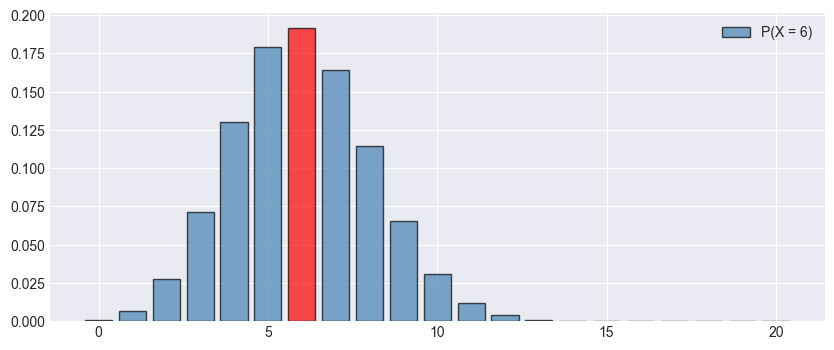

In [ ]:
calcular_binomial(
    n = 20,         # número de tentativas
    p = 0.3,        # probabilidade de sucesso
    tipo = 'pmf',   # Opções: 'pmf' (=k), 'cdf' (≤k), 'sf' (≥k), 'interval' (a≤X≤b), 'ppf' (Inverso P≤k ≥ p)
    k = 6,          # número de sucessos para pmf, cdf e sf
    a = 4,          # limite inferior para interval
    b = 10,         # limite superior para interval
    prob = 0.95     # probabilidade acumulada mínima desejada para ppf
)

## 2. Distribuição de Poisson

📊 POISSON (λ=65)
✅ Pode aproximar para NORMAL (λ=65>10)
P(X = 7) = 0.000000


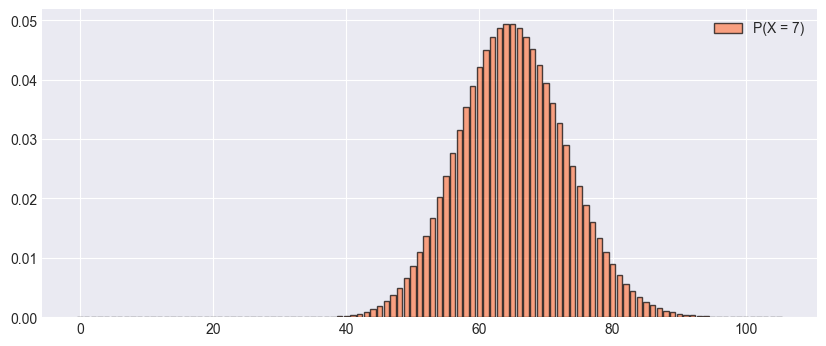

In [ ]:
calcular_poisson(
    lam = 65,      # taxa média de ocorrências (λ)
    tipo = 'pmf',   # Opções: 'pmf', 'cdf', 'sf', 'interval' ou 'ppf'
    k = 7,          # número de eventos para pmf, cdf e sf
    a = 3,          # limite inferior para interval
    b = 8,          # limite superior para interval
    prob = 0.95     # probabilidade acumulada mínima desejada para ppf
)

## 3. Distribuição Geométrica

📊 GEOMÉTRICA (p=0.3)
P(X = 5) = 0.072030


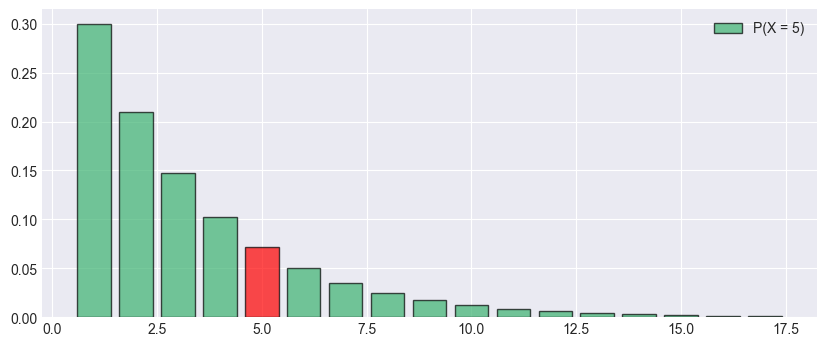

In [ ]:
calcular_geometrica(
    p = 0.3,        # probabilidade de sucesso em cada tentativa
    tipo = 'pmf',   # Opções: 'pmf', 'cdf', 'sf', 'interval' ou 'ppf'
    k = 5,          # número da tentativa em que ocorre o primeiro sucesso
    a = 2,          # limite inferior para interval
    b = 8,          # limite superior para interval
    prob = 0.95     # probabilidade acumulada mínima desejada para ppf
)

## 4. Distribuição Hipergeométrica

📊 HIPERGEOMÉTRICA (M=100, K=30, N=20)
P(X = 8) = 0.116176


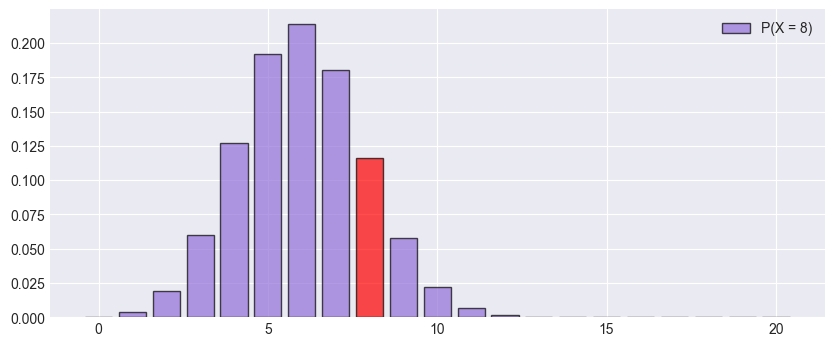

In [ ]:
calcular_hipergeometrica(
    M = 100,        # tamanho total da população
    K = 30,         # número de sucessos na população
    N = 20,         # tamanho da amostra (sem reposição)
    tipo = 'pmf',   # Opções: 'pmf', 'cdf', 'sf', 'interval' ou 'ppf'
    k = 8,          # número de sucessos na amostra
    a = 4,          # limite inferior para interval
    b = 12,         # limite superior para interval
    prob = 0.95     # probabilidade acumulada mínima desejada para ppf
)

## 5. Distribuição Binomial Negativa

📊 BINOMIAL NEGATIVA (r=5, p=0.4)
P(X = 7) = 0.094596


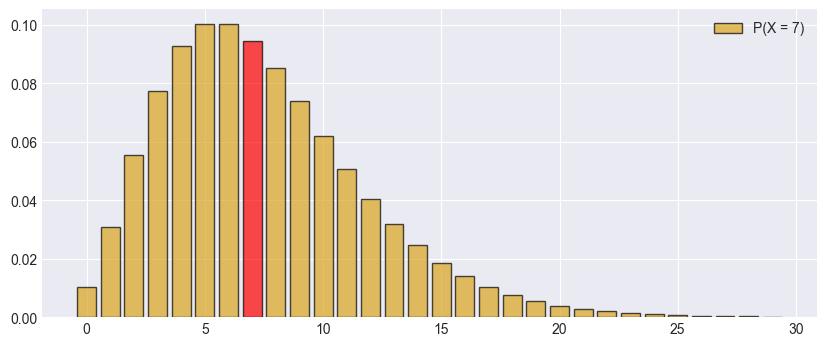

: 

In [ ]:
calcular_binomial_negativa(
    r = 5,          # número de sucessos desejados
    p = 0.4,        # probabilidade de sucesso
    tipo = 'pmf',   # Opções: 'pmf' (=k falhas), 'cdf', 'sf', 'interval' ou 'ppf'
    k = 7,          # número de falhas antes de atingir r sucessos
    a = 3,          # limite inferior para interval
    b = 12,         # limite superior para interval
    prob = 0.95     # probabilidade acumulada mínima desejada para ppf
)